# Clustering Folksonomique : Une Nouvelle Approche des Genres

## Introduction et Contexte
La classification des jeux vidéo repose traditionnellement sur des genres marketing (FPS, RPG, RTS) qui, bien que populaires, manquent souvent de précision pour décrire les mécaniques de jeu réelles. **Li & Zhang (2015)** suggèrent que les tags Steam, issus d'une folksonomie (classification collaborative par les utilisateurs), offrent une granularité bien supérieure.

Cependant, la folksonomie est bruyante et non structurée. Un même concept peut être décrit par plusieurs tags, et certains tags sont trop génériques ("Indie", "Action").

## Objectif de l'Analyse
L'objectif de ce notebook est de structurer cette folksonomie en découvrant des **"Genres Folksonomiques"** latents. Nous allons :
1.  Construire un graphe de similarité entre les tags basé sur leur co-occurrence dans les jeux.
2.  Appliquer des algorithmes de clustering (Louvain, GMM, OPTICS, K-Medoids) pour regrouper les tags sémantiquement proches.
3.  Comparer ces approches pour identifier la structure la plus robuste.
4.  Visualiser ces clusters pour comprendre les relations entre les différents genres émergents.

Cette approche bottom-up nous permettra de voir si des catégories de gameplay cohérentes émergent naturellement des données utilisateurs, sans imposer de grille de lecture préconçue.

In [22]:
import pandas as pd
import networkx as nx
import community as community_louvain
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE

# Configuration des graphiques
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Chargement de la base structurée
df_structured = pd.read_csv('../data/Games_Gameplay_Taxonomy.csv')

# Préparation d'une matrice Jeu x Tags
df_tags = df_structured[['game_id', 'Genre', 'Mechanics']].copy()
df_tags['all_tags'] = df_tags['Genre'].fillna('') + ', ' + df_tags['Mechanics'].fillna('')
df_tags['all_tags'] = df_tags['all_tags'].str.strip(', ')

# On explose les tags
tags_exploded = df_tags.assign(tag=df_tags['all_tags'].str.split(', ')).explode('tag')
tags_exploded = tags_exploded[tags_exploded['tag'].notna() & (tags_exploded['tag'] != '')]

# Filtrage des tags trop rares (pour la performance et le bruit)
tag_counts = tags_exploded['tag'].value_counts()
frequent_tags = tag_counts[tag_counts > 500].index
tags_filtered = tags_exploded[tags_exploded['tag'].isin(frequent_tags)]

print(f"Tags conservés pour le clustering : {len(frequent_tags)}")

# Création de la matrice binaire de manière optimisée
# On utilise get_dummies puis on regroupe par game_id
matrix = pd.get_dummies(tags_filtered['tag']).astype(int)
matrix['game_id'] = tags_filtered['game_id'].values
matrix = matrix.groupby('game_id').max()

print(f"Matrice binaire créée : {matrix.shape[0]} jeux x {matrix.shape[1]} tags.")

Tags conservés pour le clustering : 133
Matrice binaire créée : 99797 jeux x 133 tags.


## 1. Calcul de la Similarité entre Tags

Nous utilisons la similarité de cosinus pour mesurer à quel point deux tags partagent les mêmes jeux.

In [23]:
# Calcul de la matrice de similarité (Tags x Tags)
# On transpose la matrice (Jeux x Tags) pour avoir (Tags x Jeux)
# La similarité cosinus entre deux tags sera basée sur les jeux qu'ils ont en commun
tag_sim_matrix = cosine_similarity(matrix.T)
df_sim = pd.DataFrame(tag_sim_matrix, index=matrix.columns, columns=matrix.columns)

print("Exemple de similarités pour 'RPG':")
print(df_sim['RPG'].sort_values(ascending=False).head(10))

Exemple de similarités pour 'RPG':
RPG                  1.000000
Action RPG           0.428084
Adventure            0.393649
JRPG                 0.380420
Turn-Based Combat    0.322407
Action               0.281479
Party-Based RPG      0.276172
Strategy RPG         0.271564
Strategy             0.254643
Open World           0.252694
Name: RPG, dtype: float64


## 2. Détection de Communautés (Algorithme de Louvain)

Nous créons un graphe où un lien existe si la similarité > 0.20.

In [24]:
# Création du graphe
G = nx.Graph()

# Seuil de similarité pour créer un lien (ajustable)
threshold = 0.20

# Ajout des nœuds et des arêtes
tags = df_sim.columns
for i in range(len(tags)):
    for j in range(i + 1, len(tags)):
        sim = tag_sim_matrix[i, j]
        if sim > threshold:
            G.add_edge(tags[i], tags[j], weight=sim)

# Détection des communautés avec l'algorithme de Louvain
partition = community_louvain.best_partition(G, weight='weight')

# Organisation des tags par cluster
clusters = {}
for tag, community_id in partition.items():
    if community_id not in clusters:
        clusters[community_id] = []
    clusters[community_id].append(tag)

print(f"Nombre de communautés détectées : {len(clusters)}")
for cid, tags_in_cluster in sorted(clusters.items()):
    print(f"\nCluster {cid} ({len(tags_in_cluster)} tags) :")
    print(f"{', '.join(tags_in_cluster[:15])}...")

Nombre de communautés détectées : 11

Cluster 0 (2 tags) :
Automobile Sim, Racing...

Cluster 1 (22 tags) :
2D Platformer, Action-Adventure, Adventure, Controller, Metroidvania, Platformer, Puzzle Platformer, 3D Platformer, Parkour, Casual, Physics, Survival Horror, Point & Click, Puzzle, Walking Simulator...

Cluster 2 (10 tags) :
Action Roguelike, Roguelike, Roguelite, Procedural Generation, Card Game, Card Battler, Deckbuilding, Roguelike Deckbuilder, Trading Card Game, Solitaire...

Cluster 3 (7 tags) :
Choices Matter, Choose Your Own Adventure, Interactive Fiction, Multiple Endings, Visual Novel, Dating Sim, Otome...

Cluster 4 (2 tags) :
Flight, Space Sim...

Cluster 5 (4 tags) :
2D Fighter, Fighting, 3D Fighter, Beat 'em up...

Cluster 6 (2 tags) :
Music, Rhythm...

Cluster 7 (18 tags) :
Open World, Survival, Simulation, Automation, Building, Resource Management, Base Building, City Builder, Colony Sim, Crafting, Economy, Management, Open World Survival Craft, Sandbox, Farming S

Cette approche nous permet de découvrir des groupes de tags qui sont souvent utilisés ensemble, révélant ainsi des "genres" ou "thèmes" émergents basés sur l'expérience des joueurs plutôt que sur des classifications marketing traditionnelles.

## 3. Visualisation du Réseau de Tags

Affichons comment les tags se regroupent spatialement.

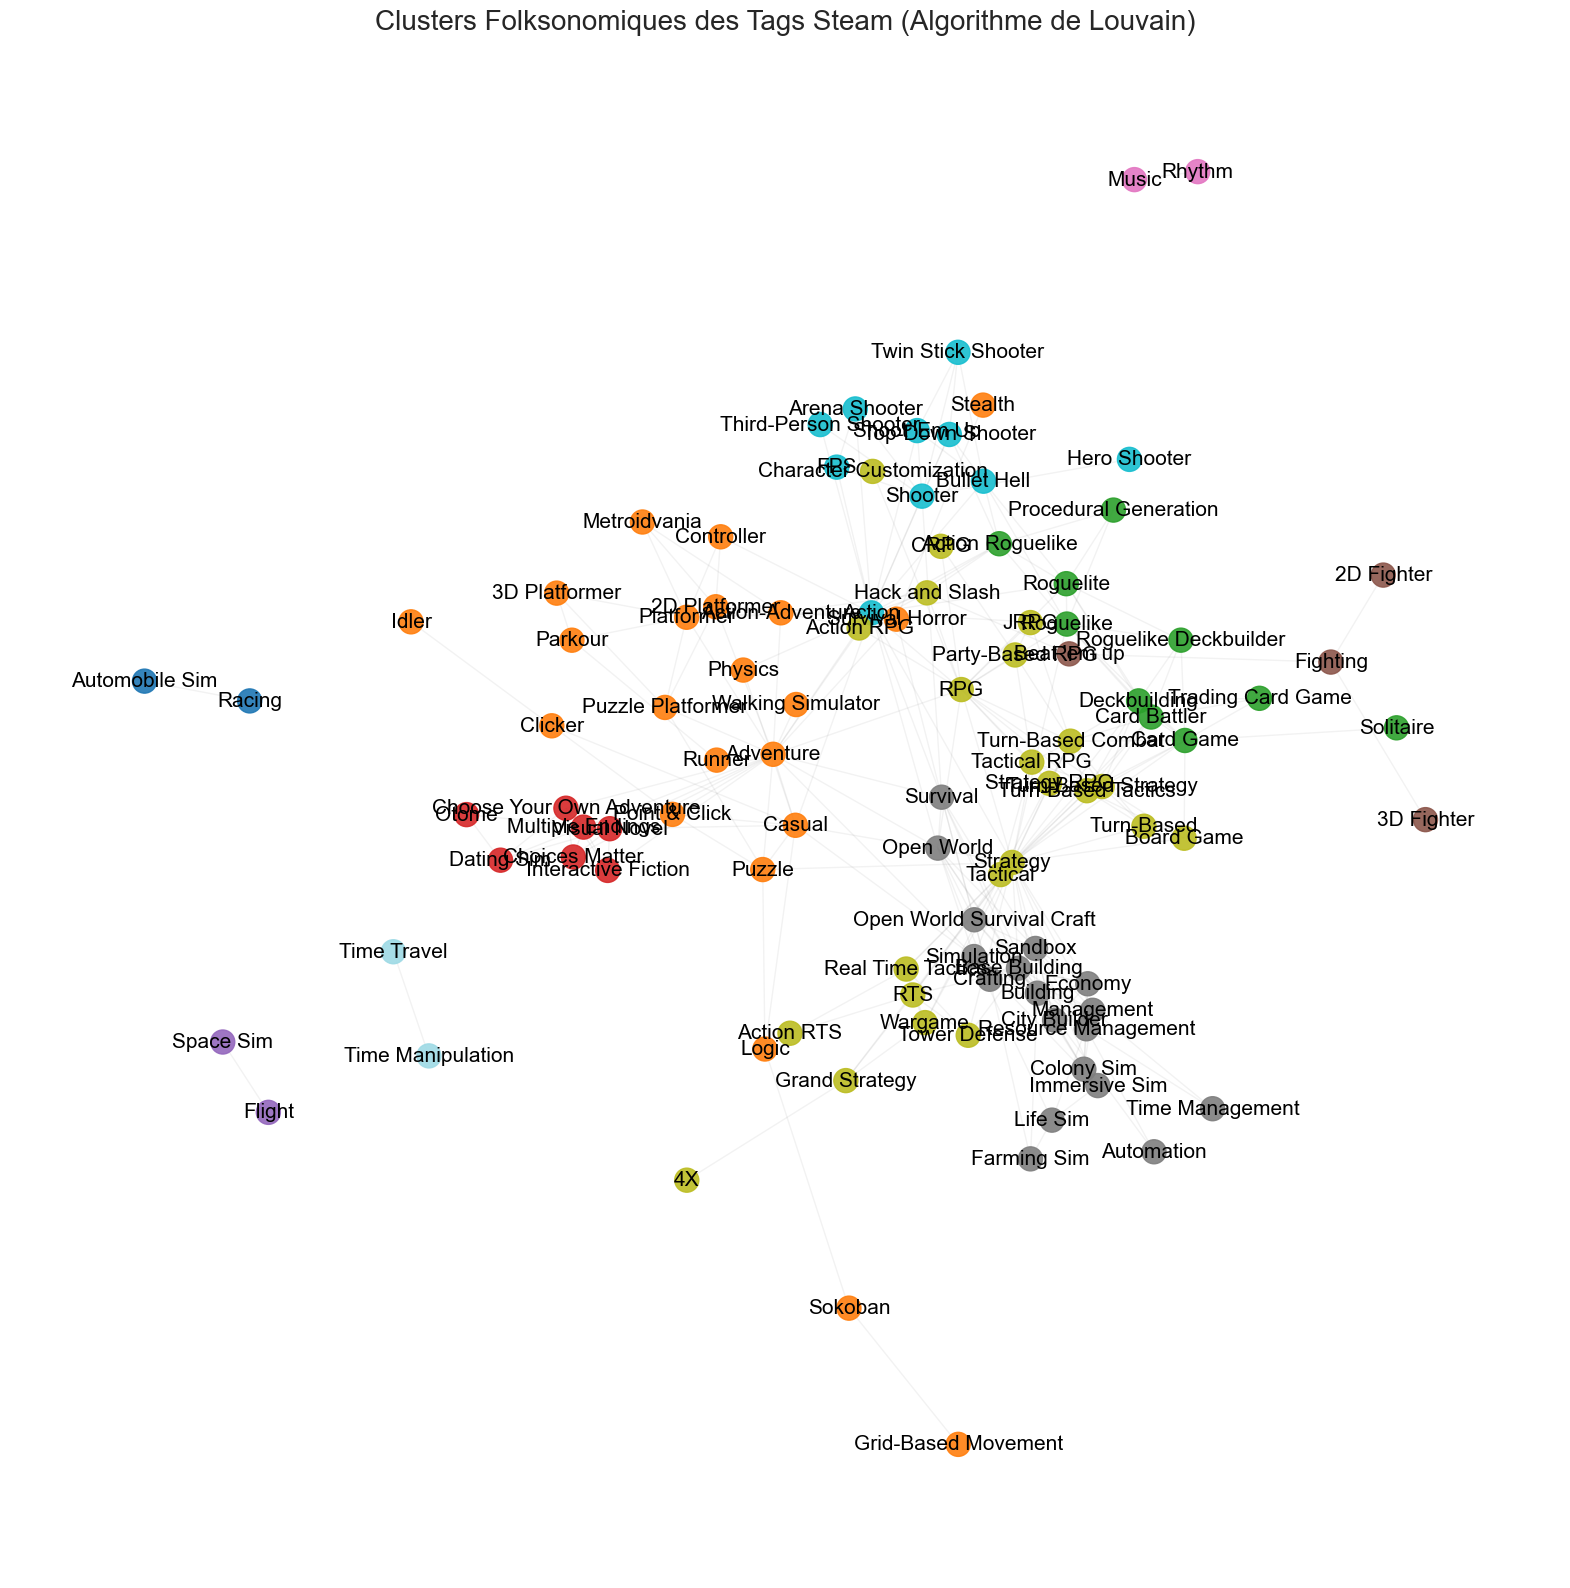

In [25]:
plt.figure(figsize=(20, 20))

# Positionnement des nœuds avec un algorithme de force
# k contrôle la distance entre les nœuds (plus k est grand, plus les nœuds sont écartés)
# iterations augmente le temps de calcul pour une meilleure convergence
pos = nx.spring_layout(G, k=0.15, iterations=50, seed=42)

# Couleur par cluster
cmap = plt.get_cmap('tab20', max(partition.values()) + 1)
node_colors = [partition[node] for node in G.nodes()]

# Dessin des nœuds
nx.draw_networkx_nodes(G, pos,
                       node_size=300,
                       node_color=node_colors,
                       cmap=cmap,
                       alpha=0.9)

# Dessin des arêtes
nx.draw_networkx_edges(G, pos, alpha=0.1, edge_color='gray')

# Dessin des labels
nx.draw_networkx_labels(G, pos, font_size=15, font_family='sans-serif')

plt.title("Clusters Folksonomiques des Tags Steam (Algorithme de Louvain)", fontsize=20)
plt.axis('off')
plt.show()

## 4. Comparaison d'autres méthodes de Clustering

Bien que l'algorithme de Louvain soit excellent pour les graphes, nous pouvons tester des approches plus traditionnelles basées sur la matrice de similarité pour voir si les clusters persistent.

Pour visualiser ces clusters, nous allons d'abord réduire la dimensionnalité de notre matrice de similarité en 2D à l'aide de t-SNE. Cela nous permettra de projeter les tags sur un plan et de colorer les points selon leur cluster d'appartenance.

In [26]:
# Réduction de dimension pour la visualisation (t-SNE)
print("Calcul de la projection t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_embedded = tsne.fit_transform(df_sim)

# Création d'un DataFrame pour la visualisation
df_viz = pd.DataFrame(X_embedded, columns=['x', 'y'], index=df_sim.index)

def plot_clusters(df_viz, labels, title, algorithm_name):
    plt.figure(figsize=(14, 10))

    # Création du scatter plot
    unique_labels = np.unique(labels)
    palette = sns.color_palette("tab20", len(unique_labels))

    sns.scatterplot(
        data=df_viz,
        x='x',
        y='y',
        hue=labels,
        palette=palette,
        legend='full',
        s=100,
        alpha=0.8
    )

    # Ajout de quelques labels pour se repérer
    # On affiche aléatoirement quelques tags pour éviter la surcharge
    texts = []
    for i, txt in enumerate(df_viz.index):
        if i % 5 == 0: # Affiche 1 tag sur 5
            texts.append(plt.text(df_viz.iloc[i]['x'], df_viz.iloc[i]['y'], txt, fontsize=9))

    plt.title(f"Visualisation des Clusters - {algorithm_name}", fontsize=16)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Cluster")
    plt.tight_layout()
    plt.show()

print("Fonction de visualisation prête.")

Calcul de la projection t-SNE...
Fonction de visualisation prête.


### 4.1. Dendrogramme (Clustering Hiérarchique)
Visualisation de la hiérarchie des tags.

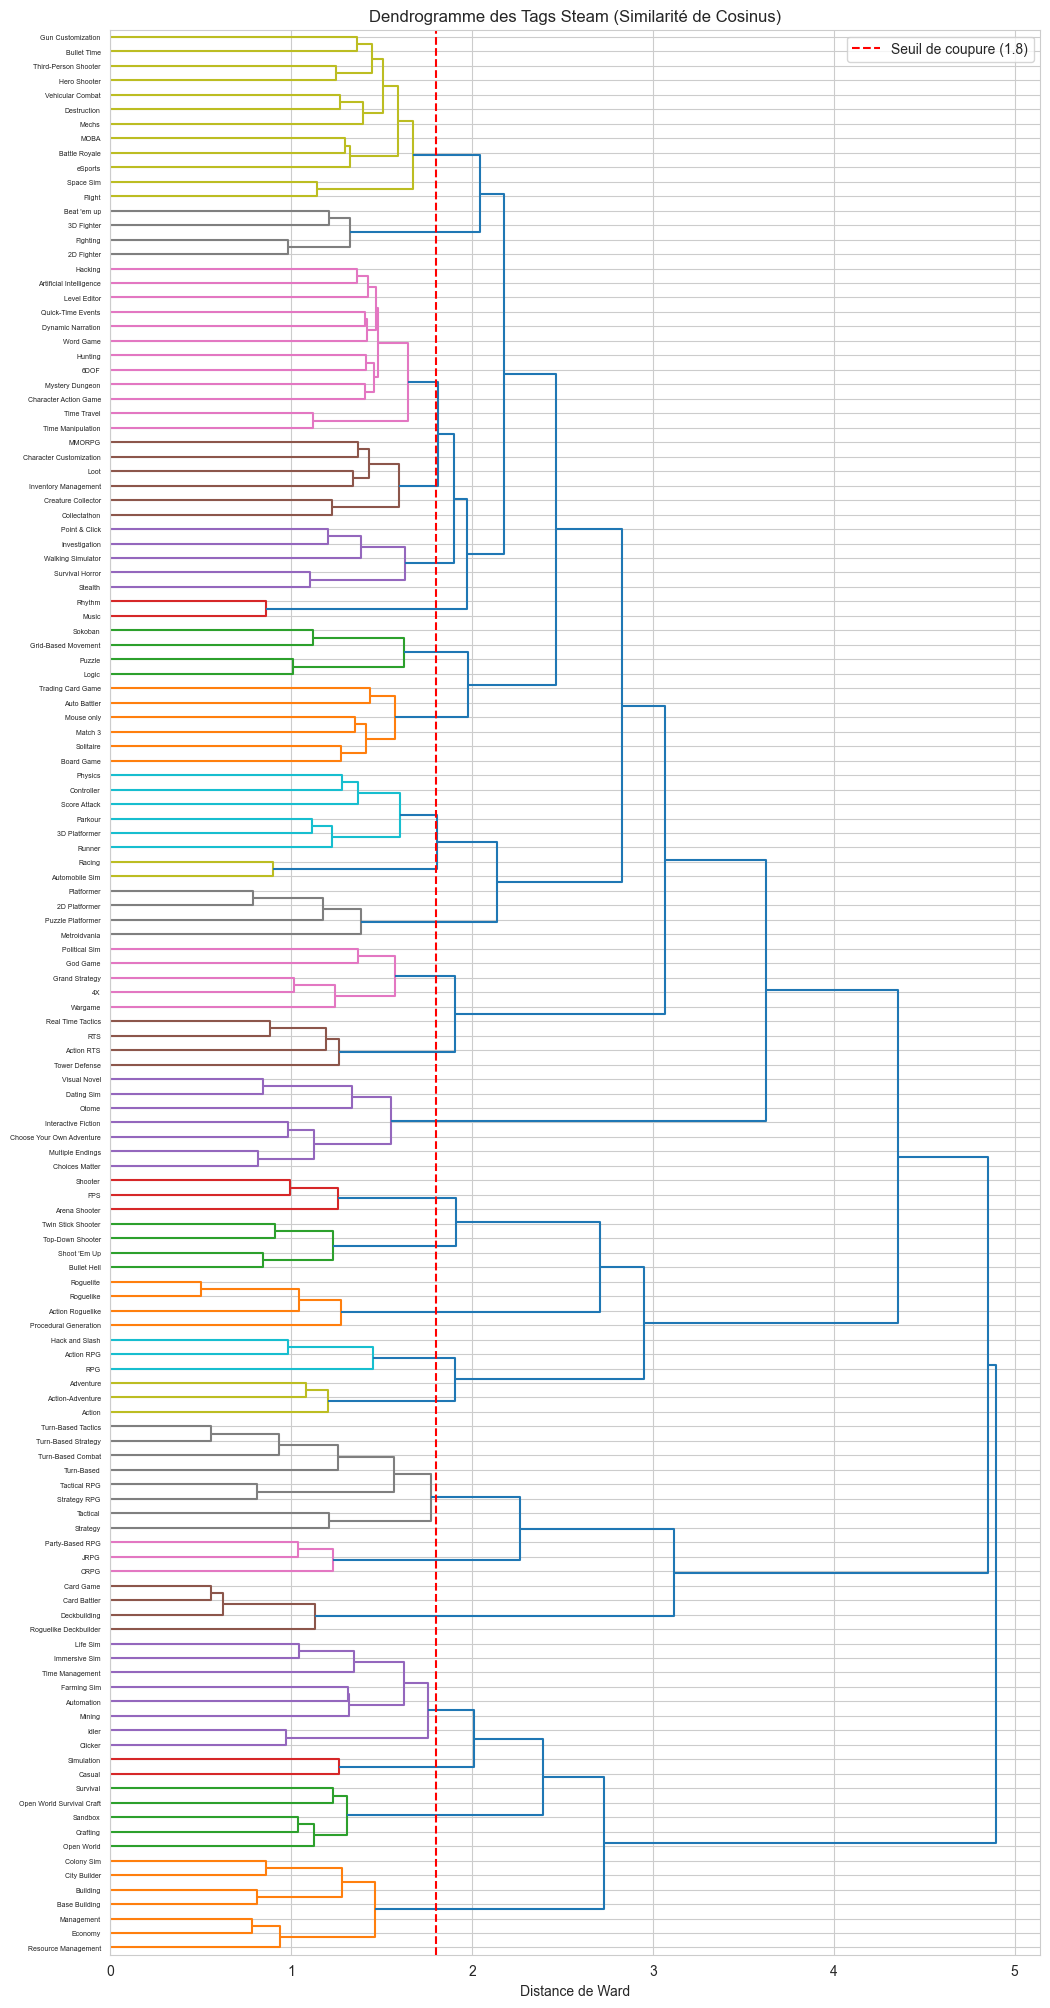

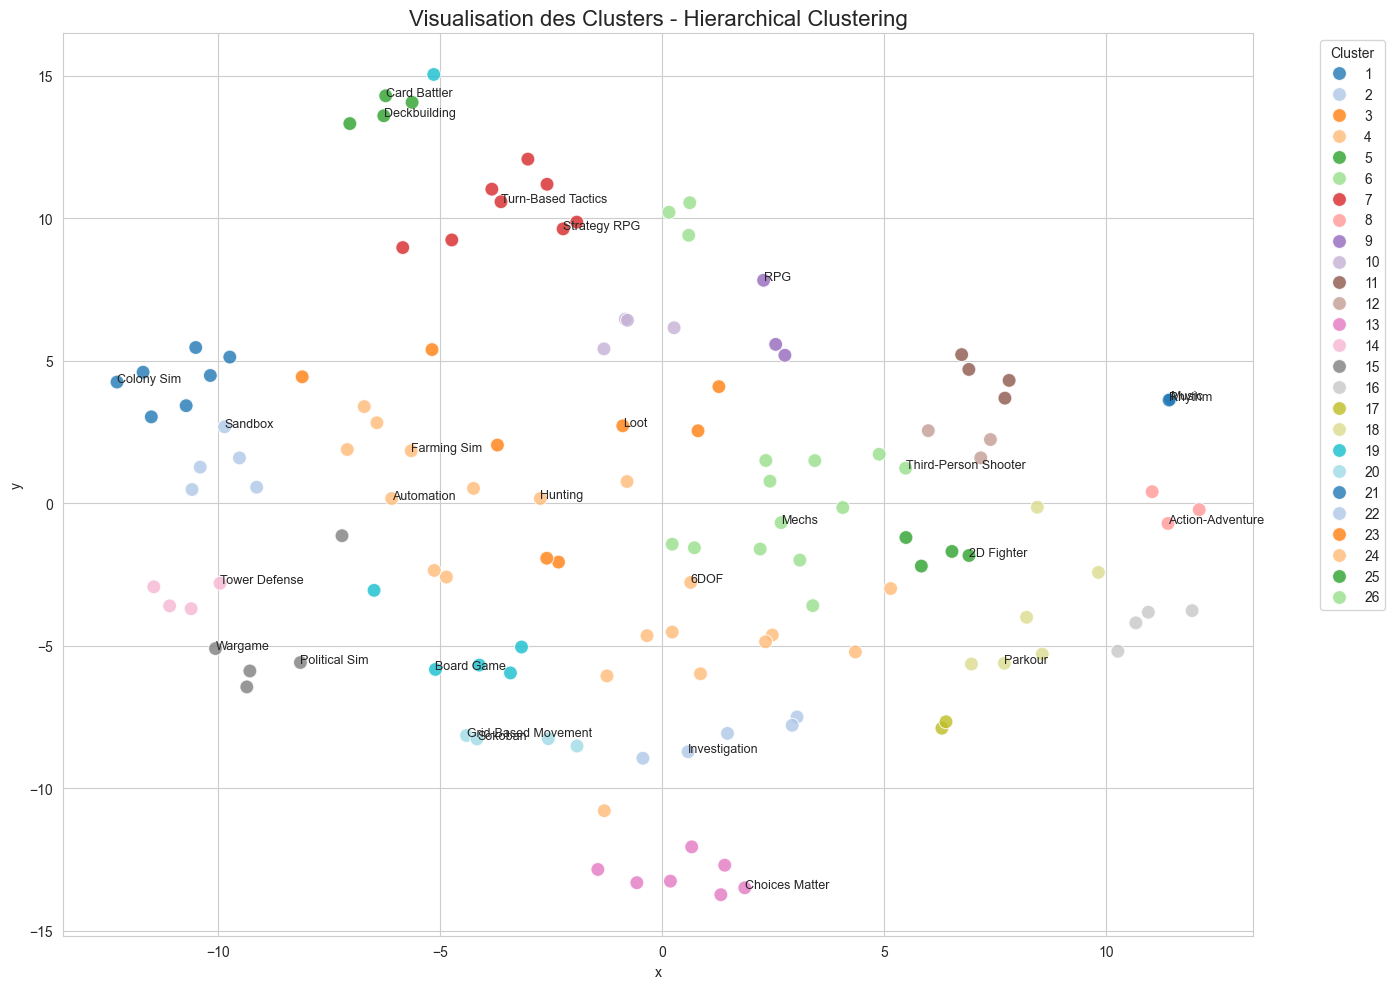

In [27]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# On utilise 1 - similarité comme distance
Z = linkage(1 - df_sim, method='ward')

# Seuil de coupure (ajustable)
threshold_val = 1.8

plt.figure(figsize=(12, 25))
dendrogram(Z, labels=df_sim.index.tolist(), orientation='right', color_threshold=threshold_val)
plt.axvline(x=threshold_val, color='r', linestyle='--', label=f'Seuil de coupure ({threshold_val})')
plt.title("Dendrogramme des Tags Steam (Similarité de Cosinus)")
plt.xlabel("Distance de Ward")
plt.legend()
plt.show()

# Récupération des clusters hiérarchiques pour visualisation
hierarchical_labels = fcluster(Z, t=threshold_val, criterion='distance')
plot_clusters(df_viz, hierarchical_labels, "Clustering Hiérarchique", "Hierarchical Clustering")

### 4.2. Gaussian Mixture Model (GMM)
Approche probabiliste pour grouper les tags.


Cluster GMM 0 :
4X, Action RTS, Grand Strategy, Political Sim, RTS, Real Time Tactics, Tower Defense, Wargame

Cluster GMM 1 :
2D Fighter, 3D Fighter, Action RPG, Action Roguelike, Beat 'em up, Character Action Game, Fighting, Hack and Slash

Cluster GMM 2 :
CRPG, Character Customization, Creature Collector, Grid-Based Movement, JRPG, Party-Based RPG, RPG

Cluster GMM 3 :
Choices Matter, Choose Your Own Adventure, Dating Sim, Interactive Fiction, Investigation, Multiple Endings, Otome, Point & Click, Visual Novel

Cluster GMM 4 :
Card Battler, Card Game, Deckbuilding, Roguelike, Roguelike Deckbuilder, Roguelite, Trading Card Game

Cluster GMM 5 :
2D Platformer, 3D Platformer, Action, Action-Adventure, Adventure, Casual, Controller, Metroidvania, Physics, Platformer, Puzzle, Puzzle Platformer

Cluster GMM 6 :
Clicker, Farming Sim, God Game, Idler, Immersive Sim, Inventory Management, Life Sim, Time Management, Walking Simulator

Cluster GMM 7 :
6DOF, Arena Shooter, Artificial Intellige

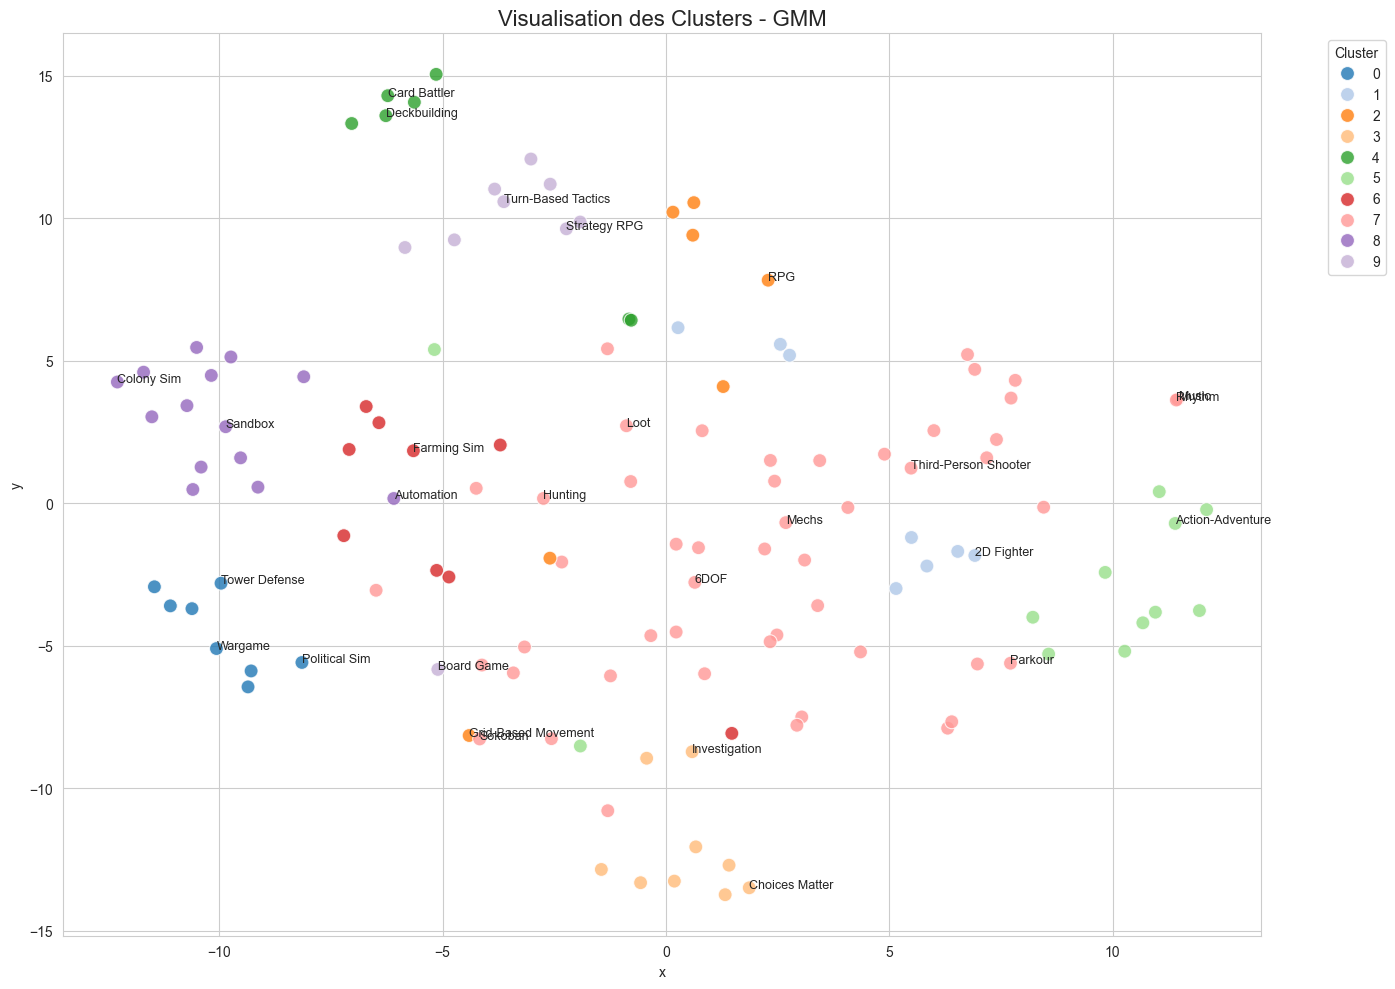

In [28]:
from sklearn.mixture import GaussianMixture

n_clusters = 10
gmm = GaussianMixture(n_components=n_clusters, random_state=42)
gmm_clusters = gmm.fit_predict(df_sim)

df_gmm = pd.DataFrame({'Tag': df_sim.index, 'Cluster': gmm_clusters})
for i in range(n_clusters):
    print(f"\nCluster GMM {i} :")
    print(", ".join(df_gmm[df_gmm['Cluster'] == i]['Tag'].values[:15]))

# Visualisation GMM
plot_clusters(df_viz, gmm_clusters, "Gaussian Mixture Model", "GMM")

### 4.3. OPTICS
Détection basée sur la densité, similaire à DBSCAN mais plus flexible pour les formes de clusters.

Nombre de clusters OPTICS : 7

Cluster OPTICS 0 :
Action, Action-Adventure, Adventure, Casual, FPS, Puzzle, Shooter

Cluster OPTICS 1 :
Economy, Management, Resource Management

Cluster OPTICS 2 :
Base Building, Building, City Builder, Colony Sim, Crafting, Sandbox

Cluster OPTICS 3 :
Action Roguelike, Procedural Generation, Roguelike, Roguelite

Cluster OPTICS 4 :
Strategy, Strategy RPG, Tactical, Tactical RPG, Turn-Based, Turn-Based Combat, Turn-Based Strategy, Turn-Based Tactics

Cluster OPTICS 5 :
Choices Matter, Choose Your Own Adventure, Dating Sim, Interactive Fiction, Multiple Endings, Visual Novel

Cluster OPTICS 6 :
Card Battler, Card Game, Deckbuilding, Roguelike Deckbuilder, Trading Card Game

Tags considérés comme bruit (-1) [Total: 94] :
2D Fighter, 2D Platformer, 3D Fighter, 3D Platformer, 4X, 6DOF, Action RPG, Action RTS, Arena Shooter, Artificial Intelligence, Auto Battler, Automation, Automobile Sim, Battle Royale, Beat 'em up, Board Game, Bullet Hell, Bullet Time, CR

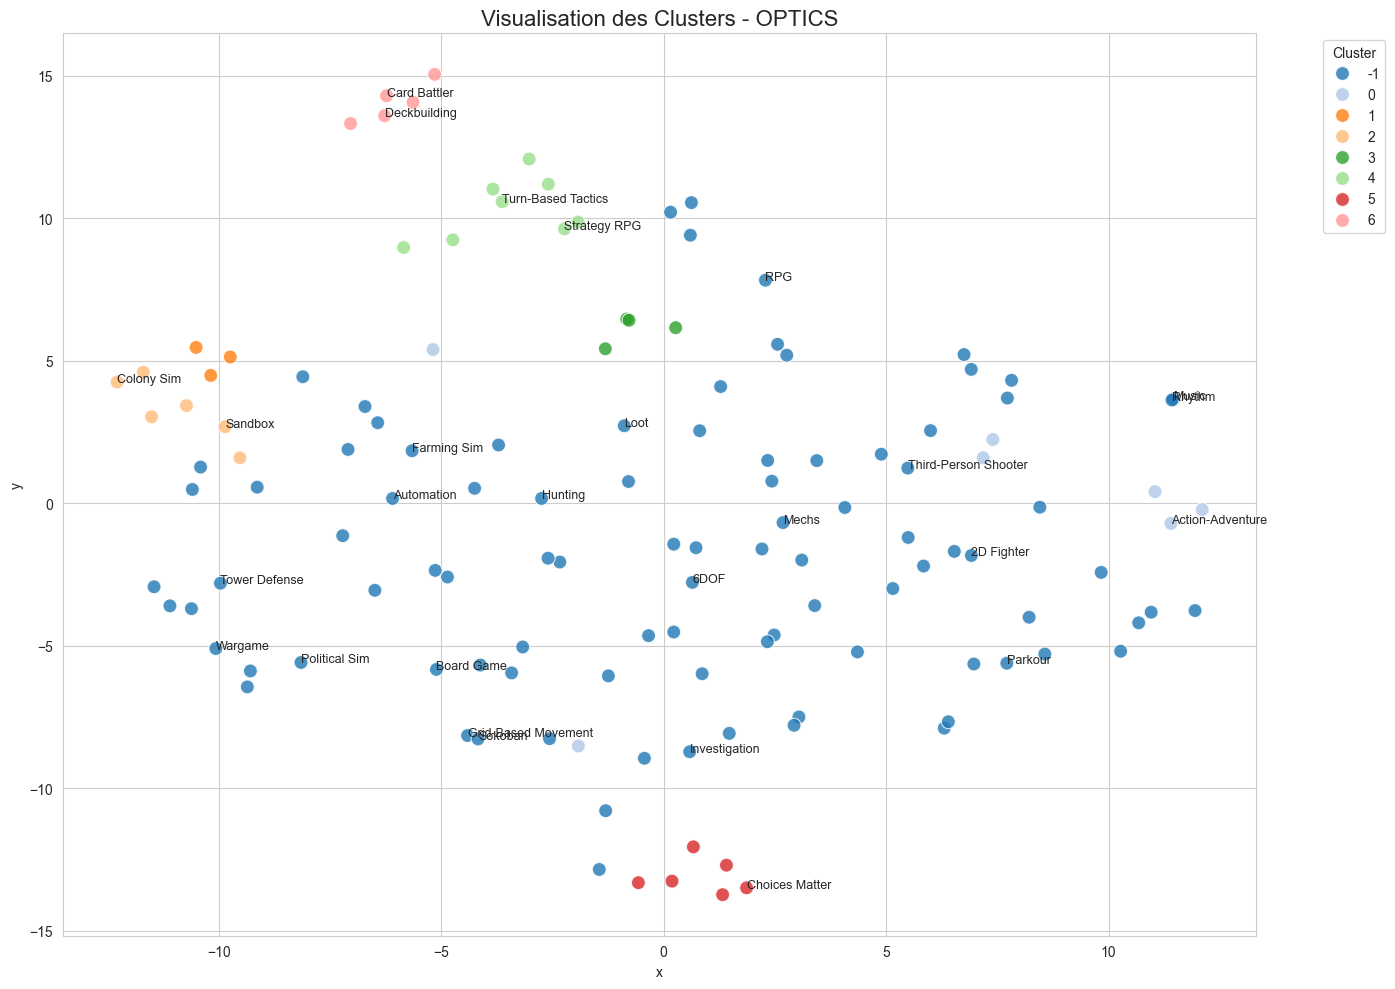

In [29]:
from sklearn.cluster import OPTICS

optics = OPTICS(min_samples=3, metric='cosine')
optics_clusters = optics.fit_predict(df_sim)

df_optics = pd.DataFrame({'Tag': df_sim.index, 'Cluster': optics_clusters})
print("Nombre de clusters OPTICS :", len(df_optics['Cluster'].unique()) - (1 if -1 in optics_clusters else 0))

# Affichage des clusters
for i in sorted(df_optics['Cluster'].unique()):
    if i == -1: continue
    print(f"\nCluster OPTICS {i} :")
    print(", ".join(df_optics[df_optics['Cluster'] == i]['Tag'].values))

# Affichage du bruit
noise_tags = df_optics[df_optics['Cluster'] == -1]['Tag'].values
print(f"\nTags considérés comme bruit (-1) [Total: {len(noise_tags)}] :")
print(", ".join(noise_tags))

# Visualisation OPTICS
plot_clusters(df_viz, optics_clusters, "OPTICS Clustering", "OPTICS")

### 4.4. K-Medoids (PAM)
Similaire à K-Means mais plus robuste aux outliers, en utilisant des médoides (tags réels) comme centres de cluster.

Médoides identifiés : ['Gun Customization', 'Puzzle', 'Visual Novel', 'Dynamic Narration', 'Time Travel', 'Building', 'Racing', 'Idler', 'Turn-Based Strategy', 'Action']

Cluster K-Medoids 0 :
Médoide : Gun Customization
Gun Customization

Cluster K-Medoids 1 :
Médoide : Puzzle
Casual, Hacking, Investigation, Level Editor, Logic, Match 3, Mouse only, Point & Click, Puzzle, Puzzle Platformer, Sokoban, Solitaire, Walking Simulator

Cluster K-Medoids 2 :
Médoide : Visual Novel
Choices Matter, Choose Your Own Adventure, Dating Sim, Interactive Fiction, Multiple Endings, Otome, Visual Novel, Word Game

Cluster K-Medoids 3 :
Médoide : Dynamic Narration
Dynamic Narration

Cluster K-Medoids 4 :
Médoide : Time Travel
Time Manipulation, Time Travel

Cluster K-Medoids 5 :
Médoide : Building
Action RTS, Automation, Base Building, Building, City Builder, Colony Sim, Crafting, Economy, Farming Sim, God Game, Immersive Sim, Inventory Management, Life Sim, Management, Mining, Open World, Open World Su

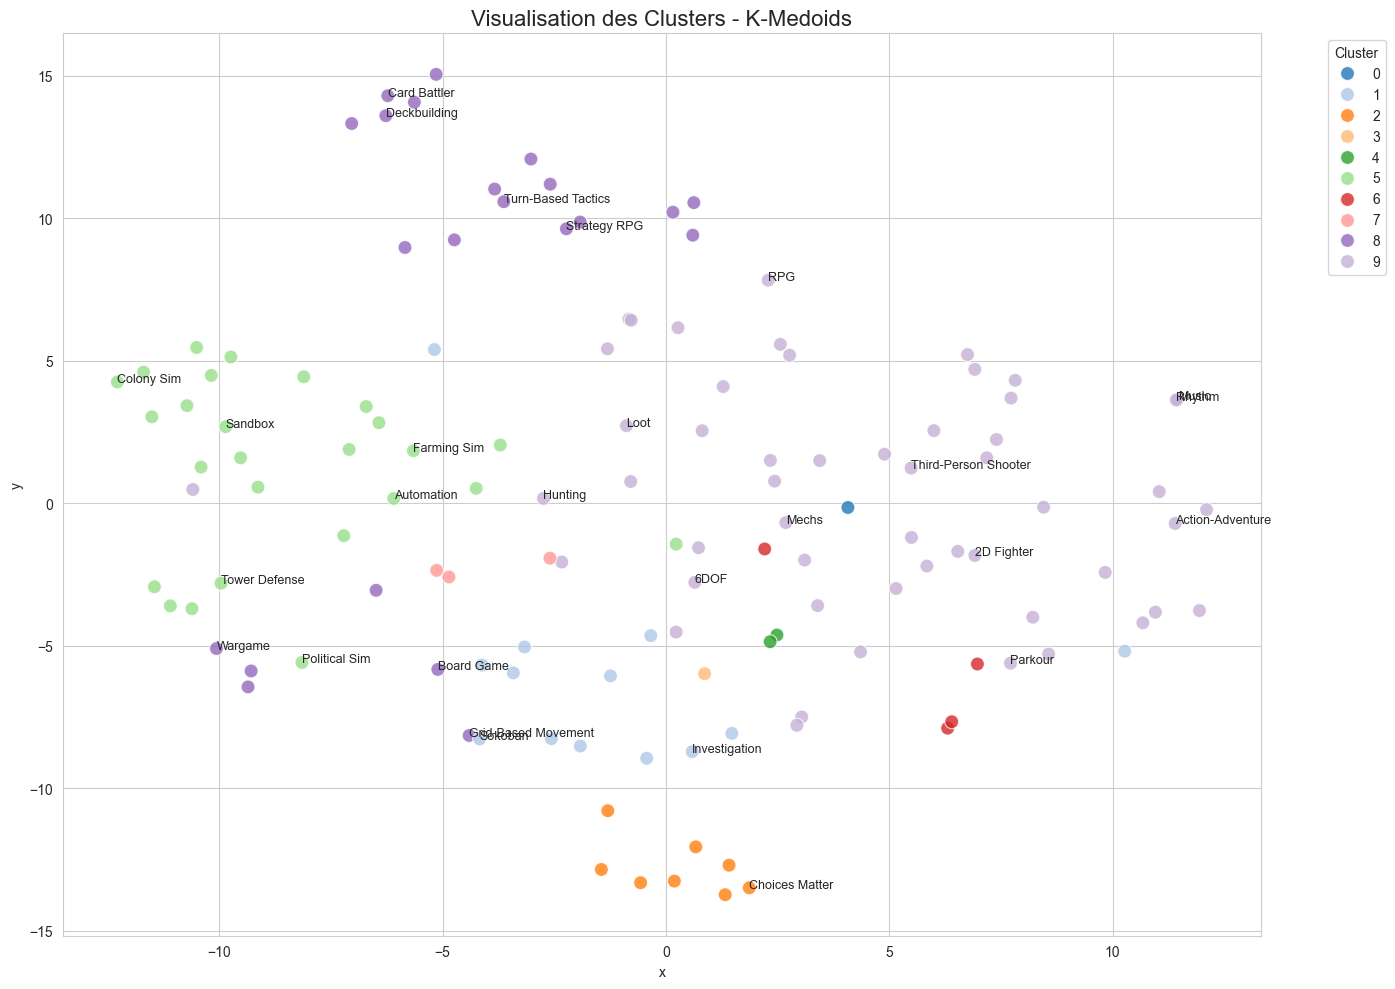

In [30]:
import numpy as np
from sklearn.metrics import pairwise_distances

def simple_kmedoids(data, k, max_iter=100):
    n_samples = data.shape[0]
    np.random.seed(42)
    medoids_idx = np.random.choice(n_samples, k, replace=False)

    for _ in range(max_iter):
        dist_matrix = pairwise_distances(data, data[medoids_idx], metric='cosine')
        clusters = np.argmin(dist_matrix, axis=1)
        new_medoids_idx = np.copy(medoids_idx)
        for i in range(k):
            cluster_points = np.where(clusters == i)[0]
            if len(cluster_points) == 0: continue
            cluster_dist = pairwise_distances(data[cluster_points], data[cluster_points], metric='cosine')
            new_medoids_idx[i] = cluster_points[np.argmin(np.sum(cluster_dist, axis=1))]
        if np.array_equal(medoids_idx, new_medoids_idx): break
        medoids_idx = new_medoids_idx
    return clusters, medoids_idx

pam_clusters, medoids_idx = simple_kmedoids(df_sim.values, k=10)
df_pam = pd.DataFrame({'Tag': df_sim.index, 'Cluster': pam_clusters})
medoid_tags = df_sim.index[medoids_idx].tolist()
print("Médoides identifiés :", medoid_tags)

for i in range(10): # On choisissant 10 clusters pour la comparaison
    print(f"\nCluster K-Medoids {i} :")
    cluster_tags = df_pam[df_pam['Cluster'] == i]['Tag'].values
    if len(cluster_tags) > 0:
        print(f"Médoide : {df_sim.index[medoids_idx[i]]}")
        print(", ".join(cluster_tags))

# Visualisation K-Medoids
plot_clusters(df_viz, pam_clusters, "K-Medoids Clustering", "K-Medoids")

## Conclusion et Synthèse

### Comparaison des Algorithmes

Nous avons testé quatre approches distinctes pour structurer la folksonomie des tags Steam :

1.  **Louvain (Approche Graphe)** :
    *   **Forces** : Très efficace pour détecter des communautés naturelles sans définir le nombre de clusters à l'avance. Les clusters sont denses et **sémantiquement très cohérents**.
    *   **Faiblesses** : Dépend du seuil de similarité choisi pour construire le graphe.
    *   **Résultat** : Probablement l'approche la plus intuitive pour ce type de données relationnelles.

2.  **Clustering Hiérarchique** :
    *   **Forces** : Permet de visualiser les relations de proximité entre tous les tags (dendrogramme). **Utile pour voir les sous-genres.**
    *   **Faiblesses** : Le choix du seuil de coupure est arbitraire. Difficile à lire avec beaucoup de tags.

3.  **GMM (Gaussian Mixture Model)** :
    *   **Forces** : Modèle probabiliste souple ("soft clustering").
    *   **Faiblesses** : Nécessite de fixer le nombre de clusters (K). Tendance à créer des clusters de taille uniforme, ce qui ne reflète pas forcément la réalité des genres (certains genres sont très petits, d'autres énormes).

4.  **OPTICS (Densité)** :
    *   **Forces** : Capable d'identifier le "bruit" (tags qui ne rentrent nulle part) et de trouver des clusters de formes arbitraires.
    *   **Faiblesses** : Beaucoup de tags (94 soit quasi 1/4) se retrouvent classés comme bruit (-1), ce qui peut être une perte d'information, ou au contraire un nettoyage bienvenu.

### Apports pour la Classification des Jeux

L'analyse révèle que **la folksonomie Steam n'est pas chaotique**. Elle possède une structure latente forte qui correspond à des réalités de gameplay.

*   **Genres Hybrides** : Les visualisations t-SNE montrent que les frontières entre les clusters ne sont pas étanches. Les jeux se situent souvent à l'intersection de plusieurs concepts (ex: RPG et Stratégie).
*   **Recommandation** : Pour la suite du projet, l'algorithme de **Louvain** semble le plus prometteur pour générer des "meta-tags" ou des catégories de haut niveau, car il respecte la topologie naturelle du réseau de co-occurrence des tags.

Ces clusters folksonomiques serviront de base solide pour comparer avec les taxonomies académiques (Elverdam & Aarseth) dans les prochaines étapes.
